In [1]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
!pip install xgboost shap plotly --quiet

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pd.set_option('display.max_columns',None)

In [4]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [12]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [13]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [17]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [18]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [19]:
df = df.dropna()

In [20]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.drop(
    'customerID',
    axis=1,
    inplace=True
)

In [23]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


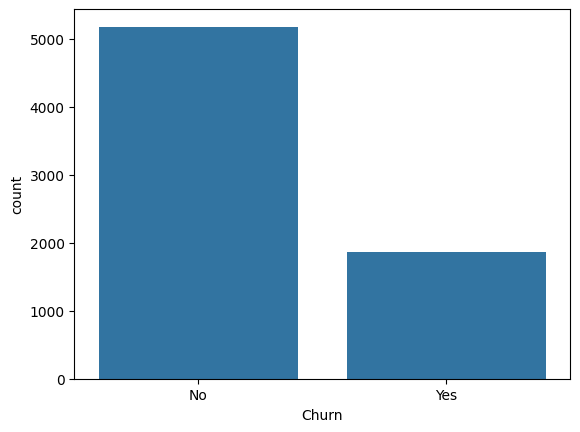

In [24]:
sns.countplot(
    x='Churn',
    data=df
)

plt.show()

In [25]:
churn_rate = (
    df['Churn']
    .value_counts(normalize=True)
    *100
)

print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


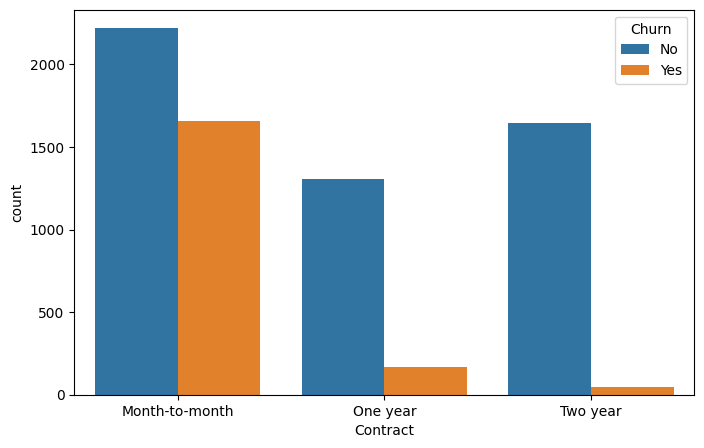

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.show()

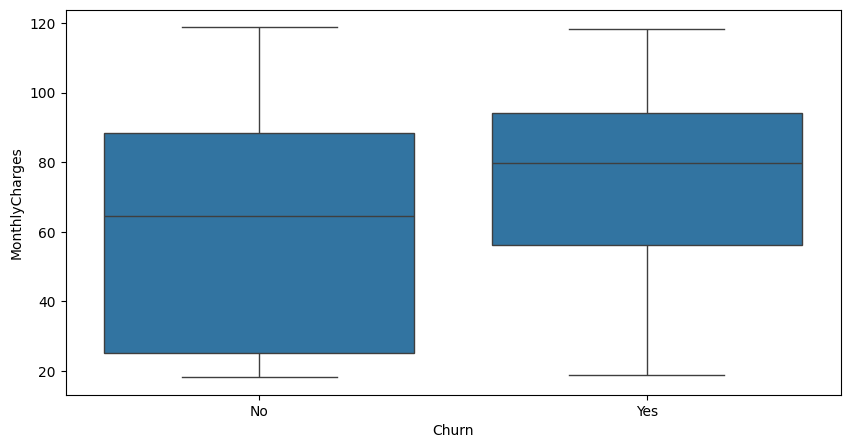

In [27]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

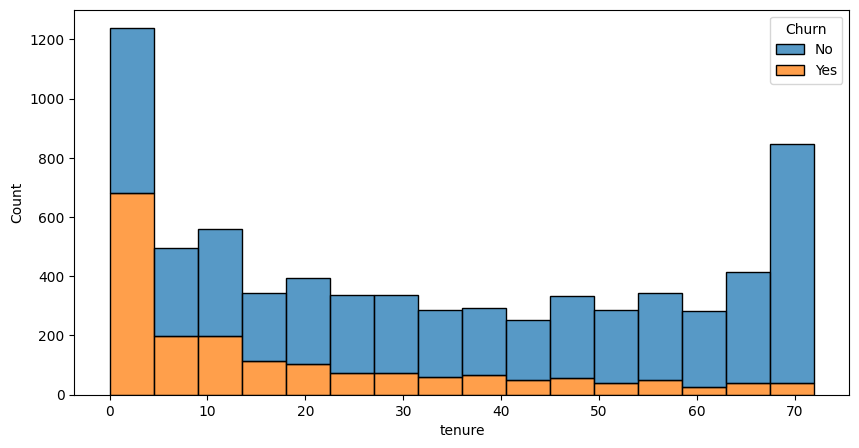

In [28]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    multiple='stack'
)

plt.show()

In [29]:
numeric_df = df.select_dtypes(
    include=np.number
)

In [30]:
print(numeric_df.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


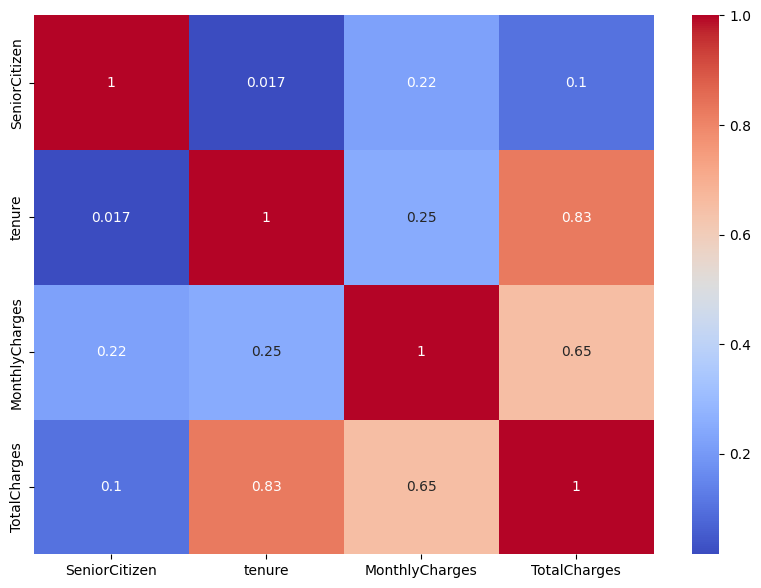

In [31]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [32]:
service_cols = [
'PhoneService',
'MultipleLines',
'OnlineSecurity',
'OnlineBackup',
'DeviceProtection',
'TechSupport',
'StreamingTV',
'StreamingMovies'
]

df['ServiceCount'] = (
    df[service_cols]
    .apply(
        lambda row:
        sum(row=='Yes'),
        axis=1
    )
)

In [33]:
df['ChargesPerMonth'] = (
    df['TotalCharges']
    /(df['tenure']+1)
)

In [34]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [35]:
df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [36]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [37]:
X = df.drop('Churn',axis=1)

y = df['Churn']

In [38]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [39]:
X.shape


(7043, 32)

In [40]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,ChargesPerMonth,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,1,14.925000,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,3,53.985714,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,3,36.050000,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,3,40.016304,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,50.550000,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [43]:
print(X_train.shape)
print(X_test.shape)

(5634, 32)
(1409, 32)


In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
lr = LogisticRegression(
    max_iter=2000
)

lr.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [46]:
from sklearn.preprocessing import StandardScaler

In [47]:
scaler = StandardScaler()

In [48]:
X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [49]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [50]:
y_pred_lr = lr.predict(
    X_test_scaled
)

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(
        y_true,
        y_pred,
        model_name):

    print(f"\n===== {model_name} =====")

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred
        )
    )

In [52]:
evaluate_model(
    y_test,
    y_pred_lr,
    "Scaled Logistic Regression"
)


===== Scaled Logistic Regression =====
Accuracy: 0.808374733853797
Precision: 0.674496644295302
Recall: 0.5374331550802139
F1: 0.5982142857142857

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [53]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [55]:
y_pred_rf = rf.predict(X_test)

In [56]:
evaluate_model(
    y_test,
    y_pred_rf,
    "Random Forest"
)


===== Random Forest =====
Accuracy: 0.8055358410220014
Precision: 0.6700680272108843
Recall: 0.5267379679144385
F1: 0.5898203592814372

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [57]:
!pip install xgboost -q

In [58]:
from xgboost import XGBClassifier

In [59]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [60]:
y_pred_xgb = xgb.predict(
    X_test
)

In [61]:
evaluate_model(
    y_test,
    y_pred_xgb,
    "XGBoost"
)


===== XGBoost =====
Accuracy: 0.7998580553584103
Precision: 0.6503267973856209
Recall: 0.5320855614973262
F1: 0.5852941176470589

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [62]:
results = pd.DataFrame({

'Model':[
'Logistic Regression',
'Random Forest',
'XGBoost'
],

'Accuracy':[

accuracy_score(
y_test,
y_pred_lr
),

accuracy_score(
y_test,
y_pred_rf
),

accuracy_score(
y_test,
y_pred_xgb
)
],

'Recall':[

recall_score(
y_test,
y_pred_lr
),

recall_score(
y_test,
y_pred_rf
),

recall_score(
y_test,
y_pred_xgb
)
],

'F1':[

f1_score(
y_test,
y_pred_lr
),

f1_score(
y_test,
y_pred_rf
),

f1_score(
y_test,
y_pred_xgb
)
]

})

results

,Model,Accuracy,Recall,F1
0,Logistic Regression,0.808375,0.537433,0.598214
1,Random Forest,0.805536,0.526738,0.589820
2,XGBoost,0.799858,0.532086,0.585294


In [63]:
from sklearn.model_selection import cross_val_score

In [64]:
lr_cv_scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("CV Scores:", lr_cv_scores)
print("Mean CV Score:", lr_cv_scores.mean())

CV Scores: [0.63079777 0.58365759 0.58691589 0.57404022 0.59099099]
Mean CV Score: 0.5932804918846882


In [65]:
rf_cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("CV Scores:", rf_cv_scores)
print("Mean CV Score:", rf_cv_scores.mean())

CV Scores: [0.60707635 0.57768924 0.5498008  0.52930057 0.54681648]
Mean CV Score: 0.5621366872884493


In [66]:
xgb_cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("CV Scores:", xgb_cv_scores)
print("Mean CV Score:", xgb_cv_scores.mean())

CV Scores: [0.63362832 0.57581574 0.57358491 0.5428051  0.54814815]
Mean CV Score: 0.5747964423076555


In [67]:
from sklearn.model_selection import GridSearchCV

In [68]:
param_grid = {

'n_estimators':[100,200],

'max_depth':[5,10,None],

'min_samples_split':[2,5]

}

In [69]:
grid_rf = GridSearchCV(

RandomForestClassifier(
random_state=42
),

param_grid,

cv=5,

scoring='f1',

n_jobs=-1

)

In [70]:
grid_rf.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [71]:
print(
    grid_rf.best_params_
)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [72]:
print(
    grid_rf.best_score_
)

0.5665274676567581


In [73]:
best_rf = grid_rf.best_estimator_

In [74]:
y_pred_best_rf = best_rf.predict(
    X_test
)

evaluate_model(
    y_test,
    y_pred_best_rf,
    "Tuned Random Forest"
)


===== Tuned Random Forest =====
Accuracy: 0.801277501774308
Precision: 0.6556291390728477
Recall: 0.5294117647058824
F1: 0.5857988165680473

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [75]:
feature_importance = pd.DataFrame({

'Feature':X.columns,

'Importance':
best_rf.feature_importances_

})

In [76]:
feature_importance = (
feature_importance
.sort_values(
'Importance',
ascending=False
)
)

In [77]:
feature_importance.head(15)

,Feature,Importance
1,tenure,0.155470
3,TotalCharges,0.146514
2,MonthlyCharges,0.095992
5,ChargesPerMonth,0.092468
12,InternetService_Fiber optic,0.074256
30,PaymentMethod_Electronic check,0.058147
27,Contract_Two year,0.054656
26,Contract_One year,0.029125
15,OnlineSecurity_Yes,0.027225
4,ServiceCount,0.027055


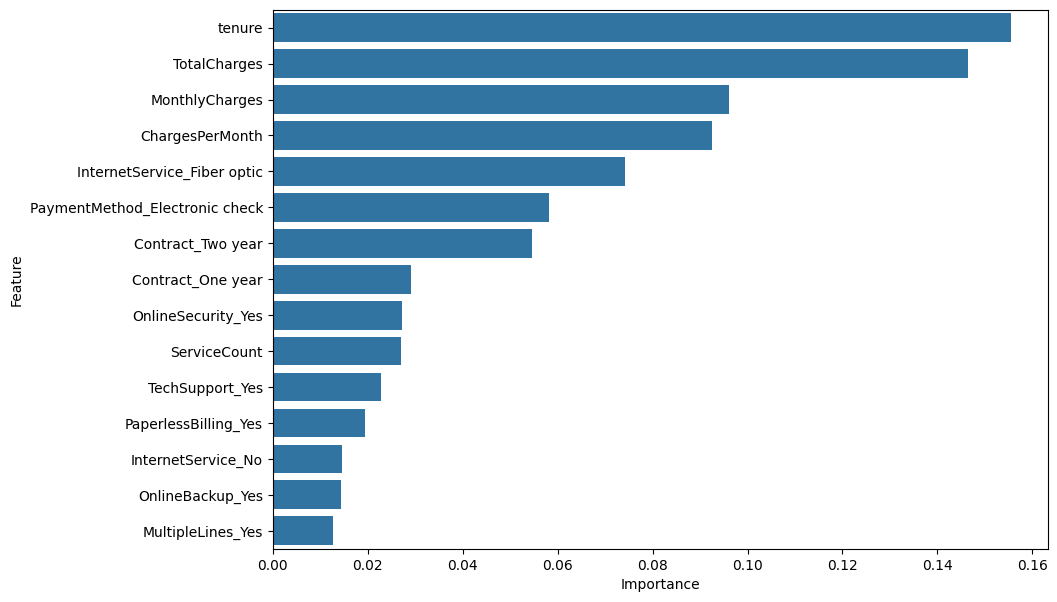

In [78]:
plt.figure(figsize=(10,7))

sns.barplot(

x='Importance',

y='Feature',

data=feature_importance.head(15)

)

plt.show()

In [79]:
!pip install shap -q

In [80]:
import shap

In [81]:
explainer = shap.TreeExplainer(
    best_rf
)

In [82]:
shap_values = explainer.shap_values(
    X_test
)

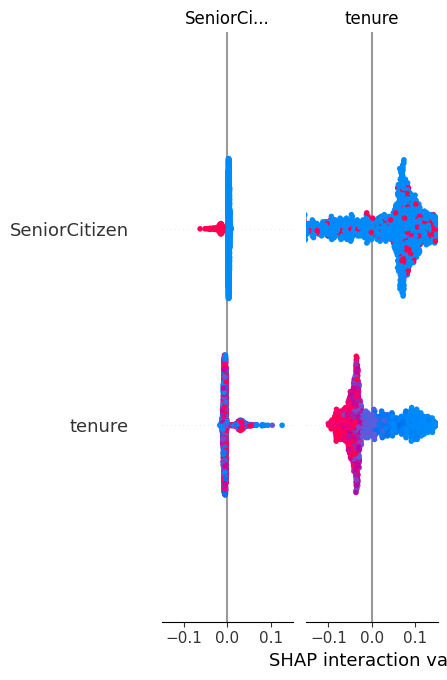

In [83]:
shap.summary_plot(
    shap_values,
    X_test
)

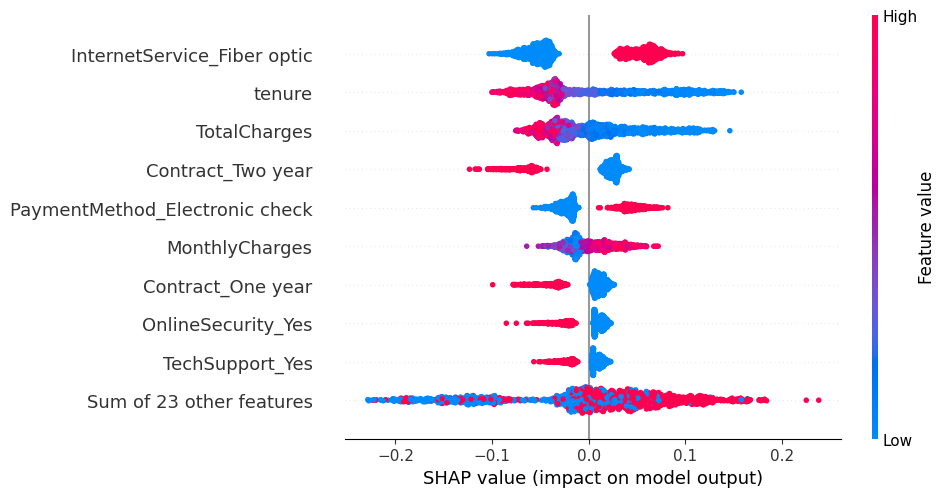

In [84]:
shap_explanation_churn = shap.Explanation(
    values=shap_values[:, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test
)

shap.plots.beeswarm(shap_explanation_churn)

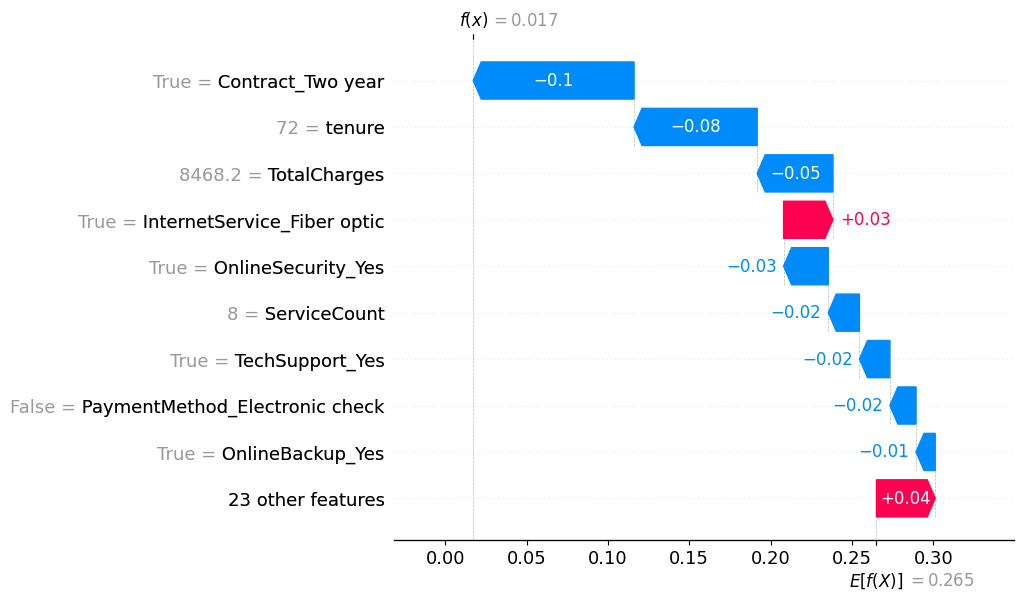

In [85]:
customer_index = 0


single_customer_explanation = shap.Explanation(
    values=shap_values[customer_index, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[customer_index]
)

shap.plots.waterfall(single_customer_explanation)

In [86]:
shap_explanation = explainer(X_test)

In [87]:
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

results_summary = pd.DataFrame({

'Model':[

'Scaled Logistic Regression',
'Random Forest',
'XGBoost',
'Tuned Random Forest'

],

'Accuracy':[

accuracy_score(
    y_test,
    y_pred_lr
),

accuracy_score(
    y_test,
    y_pred_rf
),

accuracy_score(
    y_test,
    y_pred_xgb
),

accuracy_score(
    y_test,
    y_pred_best_rf
)

],

'Precision':[

precision_score(
    y_test,
    y_pred_lr
),

precision_score(
    y_test,
    y_pred_rf
),

precision_score(
    y_test,
    y_pred_xgb
),

precision_score(
    y_test,
    y_pred_best_rf
)

],

'Recall':[

recall_score(
    y_test,
    y_pred_lr
),

recall_score(
    y_test,
    y_pred_rf
),

recall_score(
    y_test,
    y_pred_xgb
),

recall_score(
    y_test,
    y_pred_best_rf
)

],

'F1':[

f1_score(
    y_test,
    y_pred_lr
),

f1_score(
    y_test,
    y_pred_rf
),

f1_score(
    y_test,
    y_pred_xgb
),

f1_score(
    y_test,
    y_pred_best_rf
)

]

})

results_summary

,Model,Accuracy,Precision,Recall,F1
0,Scaled Logistic Regression,0.808375,0.674497,0.537433,0.598214
1,Random Forest,0.805536,0.670068,0.526738,0.589820
2,XGBoost,0.799858,0.650327,0.532086,0.585294
3,Tuned Random Forest,0.801278,0.655629,0.529412,0.585799


In [88]:
y_prob_lr = lr.predict_proba(
    X_test_scaled
)[:,1]

In [89]:
y_prob_rf = rf.predict_proba(
    X_test
)[:,1]

In [90]:
y_prob_xgb = xgb.predict_proba(
    X_test
)[:,1]

In [91]:
y_prob_best_rf = best_rf.predict_proba(
    X_test
)[:,1]

In [92]:
results_summary['ROC_AUC'] = [

roc_auc_score(
    y_test,
    y_prob_lr
),

roc_auc_score(
    y_test,
    y_prob_rf
),

roc_auc_score(
    y_test,
    y_prob_xgb
),

roc_auc_score(
    y_test,
    y_prob_best_rf
)

]

results_summary.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Scaled Logistic Regression,0.8084,0.6745,0.5374,0.5982,0.8462
1,Random Forest,0.8055,0.6701,0.5267,0.5898,0.8406
2,XGBoost,0.7999,0.6503,0.5321,0.5853,0.8390
3,Tuned Random Forest,0.8013,0.6556,0.5294,0.5858,0.8419


In [93]:
lr_balanced = LogisticRegression(

max_iter=5000,

class_weight='balanced',

random_state=42

)

lr_balanced.fit(
    X_train_scaled,
    y_train
)

y_pred_balanced = lr_balanced.predict(
    X_test_scaled
)

In [94]:
evaluate_model(
    y_test,
    y_pred_balanced,
    "Balanced Logistic Regression"
)


===== Balanced Logistic Regression =====
Accuracy: 0.7402413058907026
Precision: 0.5069204152249135
Recall: 0.7834224598930482
F1: 0.615546218487395

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [95]:
y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

threshold = 0.35

y_pred_custom = (
    y_prob >= threshold
).astype(int)

In [96]:
from imblearn.over_sampling import SMOTE

In [97]:
lr_balanced = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

lr_balanced.fit(
    X_train_scaled,
    y_train
)

y_pred_balanced = lr_balanced.predict(
    X_test_scaled
)

evaluate_model(
    y_test,
    y_pred_balanced,
    "Balanced Logistic Regression"
)


===== Balanced Logistic Regression =====
Accuracy: 0.7402413058907026
Precision: 0.5069204152249135
Recall: 0.7834224598930482
F1: 0.615546218487395

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

